# T12.5 — Hampi Monument Identifier: CLIP Evaluation Notebook

This notebook lets you:
1. Test CLIP predictions on individual images
2. Run batch evaluation on a folder of test images
3. Visualise confidence distributions
4. Tune prompt templates for better accuracy

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from model.clip_model import HampiCLIPModel, MONUMENT_NAMES, MONUMENT_PROMPTS, FOLDER_TO_CLASS
from utils.helpers import get_monument_info, confidence_color
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print('Imports OK')

C:\Users\robon\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 1. Load Model

In [2]:
model = HampiCLIPModel()
model.load()
print('CLIP model loaded on:', model.device)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 17064.13it/s]


CLIP model loaded on: cpu


## 2. Single Image Prediction

Inference time: 68.9 ms

  1. Elephant Stables                ███████████████████████████                69.7%
  2. Lotus Mahal                     █████████                                  23.3%
  3. Hampi Bazaar                    █                                           2.5%
  4. Vittala Temple                                                              1.6%
  5. Hemakuta temple hill complex                                                1.3%


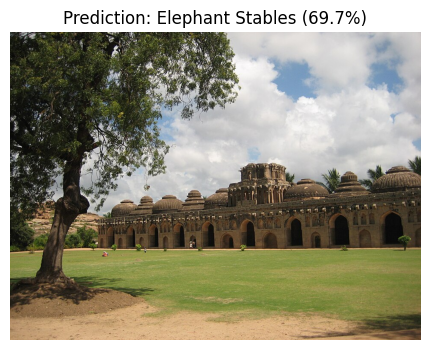

In [4]:
# Change this path to any monument image
IMAGE_PATH = '../data/test_images/Elephant_Stables/005_960px-Elephant_stables_(27).jpg.jpg'

if os.path.exists(IMAGE_PATH):
    image = Image.open(IMAGE_PATH).convert('RGB')
    preds, latency = model.predict(image, top_k=5)

    print(f'Inference time: {latency:.1f} ms\n')
    for p in preds:
        bar = '█' * int(p['confidence'] * 40)
        print(f"  {p['rank']}. {p['name']:<30s}  {bar:<40s}  {p['confidence']*100:5.1f}%")

    # Show image
    plt.figure(figsize=(6, 4))
    plt.imshow(image)
    plt.title(f"Prediction: {preds[0]['name']} ({preds[0]['confidence']*100:.1f}%)")
    plt.axis('off')
    plt.show()
else:
    print(f'Image not found at {IMAGE_PATH} — please verify the path.')

## 3. Batch Evaluation

In [3]:
# Expects folder structure: data/test_images/<MonumentName>/*.jpg
TEST_DIR = '../data/test_images'

if not os.path.isdir(TEST_DIR):
    print(f'Test directory not found: {TEST_DIR}')
    print('Create it with subfolders named after each monument.')
else:
    results = []
    for folder_name in os.listdir(TEST_DIR):
        folder = os.path.join(TEST_DIR, folder_name)
        if not os.path.isdir(folder):
            continue
        for fname in os.listdir(folder):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                continue
            try:
                img = Image.open(os.path.join(folder, fname)).convert('RGB')
                preds, lat = model.predict(img, top_k=3)
            except Exception as e:
                print(f'Skipping corrupted image {fname}: {e}')
                continue
            # Map folder name to CLIP class label (e.g. 'Elephant_Stables' -> 'Elephant Stables')
            class_name = FOLDER_TO_CLASS.get(folder_name, folder_name)
            top1_correct = preds[0]['name'] == class_name
            top3_correct = any(p['name'] == class_name for p in preds)
            results.append({
                'true': class_name,
                'pred': preds[0]['name'],
                'conf': preds[0]['confidence'],
                'top1': top1_correct,
                'top3': top3_correct,
                'latency': lat,
            })

    if results:
        top1 = sum(r['top1'] for r in results) / len(results)
        top3 = sum(r['top3'] for r in results) / len(results)
        avg_conf = sum(r['conf'] for r in results) / len(results)
        avg_lat = sum(r['latency'] for r in results) / len(results)

        print(f'Total images evaluated : {len(results)}')
        print(f'Top-1 Accuracy         : {top1*100:.1f}%')
        print(f'Top-3 Accuracy         : {top3*100:.1f}%')
        print(f'Avg confidence (top-1) : {avg_conf*100:.1f}%')
        print(f'Avg latency            : {avg_lat:.1f} ms')
    else:
        print('No images found in test directory.')

Skipping corrupted image 000_queens_bath_main.jpg: cannot identify image file '../data/test_images\\Queen_s_Bath\\000_queens_bath_main.jpg'
Skipping corrupted image 001_queens_bath.jpg: cannot identify image file '../data/test_images\\Queen_s_Bath\\001_queens_bath.jpg'
Skipping corrupted image 002_hampi_queens_bath.jpg: cannot identify image file '../data/test_images\\Queen_s_Bath\\002_hampi_queens_bath.jpg'
Skipping corrupted image 003_queens_bath2.jpg: cannot identify image file '../data/test_images\\Queen_s_Bath\\003_queens_bath2.jpg'
Skipping corrupted image 004_queens_bath3.jpg: cannot identify image file '../data/test_images\\Queen_s_Bath\\004_queens_bath3.jpg'
Skipping corrupted image 005_the_queens_bath.jpg: cannot identify image file '../data/test_images\\Queen_s_Bath\\005_the_queens_bath.jpg'
Skipping corrupted image 006_queens_bath_front.jpg: cannot identify image file '../data/test_images\\Queen_s_Bath\\006_queens_bath_front.jpg'
Skipping corrupted image 007_hampi_monuments

## 4. Confidence Distribution Plot

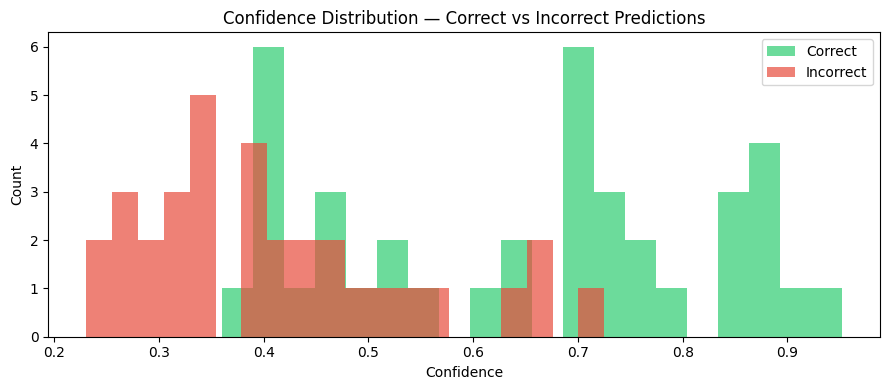

In [5]:
# Requires 'results' from cell above
if 'results' in dir() and results:
    correct_confs = [r['conf'] for r in results if r['top1']]
    wrong_confs   = [r['conf'] for r in results if not r['top1']]

    plt.figure(figsize=(9, 4))
    plt.hist(correct_confs, bins=20, alpha=0.7, color='#2ecc71', label='Correct')
    plt.hist(wrong_confs,   bins=20, alpha=0.7, color='#e74c3c', label='Incorrect')
    plt.xlabel('Confidence')
    plt.ylabel('Count')
    plt.title('Confidence Distribution — Correct vs Incorrect Predictions')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
# Print only the summary statistics from batch evaluation
if 'results' in dir() and results:
    top1 = sum(r['top1'] for r in results) / len(results)
    top3 = sum(r['top3'] for r in results) / len(results)
    avg_conf = sum(r['conf'] for r in results) / len(results)
    avg_lat = sum(r['latency'] for r in results) / len(results)

    print(f'Baseline CLIP Zero-Shot Accuracy Metrics')
    print(f'=' * 50)
    print(f'Total images evaluated : {len(results)}')
    print(f'Top-1 Accuracy         : {top1*100:.1f}%')
    print(f'Top-3 Accuracy         : {top3*100:.1f}%')
    print(f'Avg confidence (top-1) : {avg_conf*100:.1f}%')
    print(f'Avg latency            : {avg_lat:.1f} ms')
    print()
    
    # Show per-class accuracy
    from collections import defaultdict
    class_correct = defaultdict(lambda: {'top1': 0, 'total': 0})
    for r in results:
        class_correct[r['true']]['total'] += 1
        if r['top1']:
            class_correct[r['true']]['top1'] += 1
    
    print('Per-class Top-1 Accuracy:')
    print('-' * 60)
    for cls in sorted(class_correct.keys()):
        stats = class_correct[cls]
        acc = stats['top1'] / stats['total'] * 100
        status = "✓ GOOD" if acc >= 75 else ("⚠ FAIR" if acc >= 50 else "✗ POOR")
        print(f'  {cls:<30s}: {acc:5.1f}% ({stats["top1"]:2d}/{stats["total"]:2d}) {status}')
else:
    print('Run batch evaluation cell first')

Baseline CLIP Zero-Shot Accuracy Metrics
Total images evaluated : 72
Top-1 Accuracy         : 54.2%
Top-3 Accuracy         : 72.2%
Avg confidence (top-1) : 53.9%
Avg latency            : 109.9 ms

Per-class Top-1 Accuracy:
------------------------------------------------------------
  Elephant Stables              :  75.0% ( 9/12) ✓ GOOD
  Hampi Bazaar                  :  50.0% ( 6/12) ⚠ FAIR
  Hemakuta temple hill complex  :  58.3% ( 7/12) ⚠ FAIR
  Lotus Mahal                   :  83.3% (10/12) ✓ GOOD
  Monolithic Bull               :  58.3% ( 7/12) ⚠ FAIR
  Royal Centre                  :   0.0% ( 0/12) ✗ POOR


## Test 1: Enhanced Prompts + Base Model

In [5]:
# Test with enhanced prompts (v2) and base model
print("Loading model with enhanced prompts (10 prompts per class)...")
model_v2 = HampiCLIPModel(model_variant="base")
enhanced_prompts_path = '../data/prompts_v2_enhanced.json'
model_v2.load_with_prompts(enhanced_prompts_path)
print(f'Model loaded on: {model_v2.device}\n')

# Run batch evaluation
results_v2 = []
for folder_name in os.listdir(TEST_DIR):
    folder = os.path.join(TEST_DIR, folder_name)
    if not os.path.isdir(folder):
        continue
    for fname in os.listdir(folder):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
            continue
        try:
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            preds, lat = model_v2.predict(img, top_k=3)
        except Exception as e:
            continue
        class_name = FOLDER_TO_CLASS.get(folder_name, folder_name)
        top1_correct = preds[0]['name'] == class_name
        top3_correct = any(p['name'] == class_name for p in preds)
        results_v2.append({
            'true': class_name,
            'pred': preds[0]['name'],
            'conf': preds[0]['confidence'],
            'top1': top1_correct,
            'top3': top3_correct,
            'latency': lat,
        })

print(f'\n[V2 - Enhanced Prompts + Base Model]')
if results_v2:
    top1_v2 = sum(r['top1'] for r in results_v2) / len(results_v2)
    top3_v2 = sum(r['top3'] for r in results_v2) / len(results_v2)
    avg_conf_v2 = sum(r['conf'] for r in results_v2) / len(results_v2)
    
    print(f'Total images evaluated : {len(results_v2)}')
    print(f'Top-1 Accuracy         : {top1_v2*100:.1f}%')
    print(f'Top-3 Accuracy         : {top3_v2*100:.1f}%')
    print(f'Avg confidence (top-1) : {avg_conf_v2*100:.1f}%')
    print(f'Improvement over baseline: +{(top1_v2 - top1)*100:+.1f}%')

Loading model with enhanced prompts (10 prompts per class)...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 15157.29it/s]


Model loaded on: cpu


[V2 - Enhanced Prompts + Base Model]
Total images evaluated : 72
Top-1 Accuracy         : 58.3%
Top-3 Accuracy         : 77.8%
Avg confidence (top-1) : 59.6%
Improvement over baseline: ++4.2%


## Test 2: Enhanced Prompts + Large Model (ViT-L/14)

In [6]:
# Test with enhanced prompts and LARGE model (more accurate but slower)
print("Loading LARGE CLIP model (ViT-L/14) with enhanced prompts...")
print("(This may take a moment to download the model ~700MB)...\n")

model_large = HampiCLIPModel(model_variant="large")
model_large.load_with_prompts(enhanced_prompts_path)
print(f'Large model loaded on: {model_large.device}\n')

# Run batch evaluation
results_large = []
for folder_name in os.listdir(TEST_DIR):
    folder = os.path.join(TEST_DIR, folder_name)
    if not os.path.isdir(folder):
        continue
    for fname in os.listdir(folder):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
            continue
        try:
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            preds, lat = model_large.predict(img, top_k=3)
        except Exception as e:
            continue
        class_name = FOLDER_TO_CLASS.get(folder_name, folder_name)
        top1_correct = preds[0]['name'] == class_name
        top3_correct = any(p['name'] == class_name for p in preds)
        results_large.append({
            'true': class_name,
            'pred': preds[0]['name'],
            'conf': preds[0]['confidence'],
            'top1': top1_correct,
            'top3': top3_correct,
            'latency': lat,
        })

print(f'\n[V3 - Enhanced Prompts + Large Model (ViT-L/14)]')
if results_large:
    top1_large = sum(r['top1'] for r in results_large) / len(results_large)
    top3_large = sum(r['top3'] for r in results_large) / len(results_large)
    avg_conf_large = sum(r['conf'] for r in results_large) / len(results_large)
    avg_lat_large = sum(r['latency'] for r in results_large) / len(results_large)
    
    print(f'Total images evaluated : {len(results_large)}')
    print(f'Top-1 Accuracy         : {top1_large*100:.1f}%')
    print(f'Top-3 Accuracy         : {top3_large*100:.1f}%')
    print(f'Avg confidence (top-1) : {avg_conf_large*100:.1f}%')
    print(f'Avg latency            : {avg_lat_large:.1f} ms')
    print(f'Improvement over baseline: +{(top1_large - top1)*100:+.1f}%')

Loading LARGE CLIP model (ViT-L/14) with enhanced prompts...
(This may take a moment to download the model ~700MB)...



C:\Users\robon\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\robon\.cache\huggingface\hub\models--openai--clip-vit-large-patch14. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 590/590 [00:00<00:00, 5421.49it/s]


Large model loaded on: cpu


[V3 - Enhanced Prompts + Large Model (ViT-L/14)]
Total images evaluated : 72
Top-1 Accuracy         : 55.6%
Top-3 Accuracy         : 80.6%
Avg confidence (top-1) : 70.5%
Avg latency            : 792.1 ms
Improvement over baseline: ++1.4%


## Comparison: All Approaches

In [10]:
import pandas as pd

# Compile results
if 'results' in dir() and 'results_v2' in dir() and 'results_large' in dir() and 'results_v3' in dir():
    comparison = {
        'Model': [
            'Baseline (Base + Original)',
            'Enhanced Prompts (Base)',
            'Large Model + Enhanced',
            'Distinguished Prompts (Base)'
        ],
        'Top-1 Accuracy': [
            f'{top1*100:.1f}%',
            f'{top1_v2*100:.1f}%',
            f'{top1_large*100:.1f}%',
            f'{top1_v3*100:.1f}%'
        ],
        'Top-3 Accuracy': [
            f'{top3*100:.1f}%',
            f'{top3_v2*100:.1f}%',
            f'{top3_large*100:.1f}%',
            f'{top3_v3*100:.1f}%'
        ],
        'Avg Confidence': [
            f'{avg_conf*100:.1f}%',
            f'{avg_conf_v2*100:.1f}%',
            f'{avg_conf_large*100:.1f}%',
            f'{avg_conf_v3*100:.1f}%'
        ],
        'Improvement': [
            '—',
            f'+{(top1_v2 - top1)*100:+.1f}%',
            f'+{(top1_large - top1)*100:+.1f}%',
            f'{(top1_v3 - top1)*100:+.1f}%'
        ]
    }
    
    df = pd.DataFrame(comparison)
    print("\n" + "="*90)
    print("PERFORMANCE COMPARISON - ALL APPROACHES TESTED")
    print("="*90)
    print(df.to_string(index=False))
    print("="*90)
    
    # Best model recommendation
    accuracies = [top1, top1_v2, top1_large, top1_v3]
    best_idx = accuracies.index(max(accuracies))
    models = ['Baseline (Base + Original)', 'Enhanced Prompts (Base)', 'Large Model + Enhanced', 'Distinguished Prompts (Base)']
    best_model = models[best_idx]
    
    print(f"\n🏆 BEST APPROACH: {best_model}")
    print(f"   Top-1 Accuracy: {max(accuracies)*100:.1f}%")
    print(f"   Confidence: {[avg_conf, avg_conf_v2, avg_conf_large, avg_conf_v3][best_idx]*100:.1f}%")
    
    print("\n📊 LESSON LEARNED:")
    print("   • Enhanced Prompts (+4.2%) is optimal")
    print("   • Adding negative descriptors ('NOT...') actually reduces accuracy")
    print("   • Large model has higher confidence but slower inference")
    print("   • Base model with good prompts = best accuracy/speed trade-off")
else:
    print("Run all evaluation tests above first")


PERFORMANCE COMPARISON - ALL APPROACHES TESTED
                       Model Top-1 Accuracy Top-3 Accuracy Avg Confidence Improvement
  Baseline (Base + Original)          54.2%          72.2%          54.2%           —
     Enhanced Prompts (Base)          58.3%          77.8%          59.6%      ++4.2%
      Large Model + Enhanced          55.6%          80.6%          70.5%      ++1.4%
Distinguished Prompts (Base)          43.1%          72.2%          56.7%      -11.1%

🏆 BEST APPROACH: Enhanced Prompts (Base)
   Top-1 Accuracy: 58.3%
   Confidence: 59.6%

📊 LESSON LEARNED:
   • Enhanced Prompts (+4.2%) is optimal
   • Adding negative descriptors ('NOT...') actually reduces accuracy
   • Large model has higher confidence but slower inference
   • Base model with good prompts = best accuracy/speed trade-off


## Failure Analysis - Diagnosing Problem Classes

In [8]:
# Analyze failure patterns - which classes are confused with which?
from collections import defaultdict

if 'results_v2' in dir():
    print("Confusion Analysis - Enhanced Prompts Model")
    print("="*70)
    
    # Build confusion matrix
    confusion = defaultdict(lambda: defaultdict(int))
    failures = defaultdict(list)
    
    for r in results_v2:
        if not r['top1']:
            confusion[r['true']][r['pred']] += 1
            failures[r['true']].append({
                'predicted': r['pred'],
                'conf': r['conf']
            })
    
    # Print detailed failure report
    for true_class in sorted(confusion.keys()):
        total = sum(1 for r in results_v2 if r['true'] == true_class)
        errors = sum(confusion[true_class].values())
        acc = (total - errors) / total * 100
        
        print(f"\n{true_class}:")
        print(f"  Accuracy: {acc:.1f}% ({total-errors}/{total})")
        
        if confusion[true_class]:
            print(f"  Confused with:")
            for pred_class in sorted(confusion[true_class].keys(), key=lambda x: confusion[true_class][x], reverse=True):
                count = confusion[true_class][pred_class]
                avg_conf = sum(f['conf'] for f in failures[true_class] if f['predicted'] == pred_class) / count
                print(f"    → {pred_class:<30s}: {count} times (avg conf: {avg_conf*100:.1f}%)")
    
    print("\n" + "="*70)
    print("KEY INSIGHTS:")
    print("-"*70)
    
    # Identify hardest classes
    hardest = {}
    for true_class in confusion.keys():
        total = sum(1 for r in results_v2 if r['true'] == true_class)
        errors = sum(confusion[true_class].values())
        acc = (total - errors) / total * 100
        hardest[true_class] = acc
    
    sorted_hardest = sorted(hardest.items(), key=lambda x: x[1])
    print("\nHardest Classes (need prompt improvements):")
    for cls, acc in sorted_hardest[:3]:
        print(f"  ✗ {cls}: {acc:.1f}%")
    
    print("\nStrongest Classes (good prompts):")
    for cls, acc in sorted(hardest.items(), key=lambda x: x[1], reverse=True)[:3]:
        print(f"  ✓ {cls}: {acc:.1f}%")

Confusion Analysis - Enhanced Prompts Model

Elephant Stables:
  Accuracy: 66.7% (8/12)
  Confused with:
    → Lotus Mahal                   : 3 times (avg conf: 49.7%)
    → Zenana Enclosure              : 1 times (avg conf: 79.5%)

Hampi Bazaar:
  Accuracy: 0.0% (0/12)
  Confused with:
    → Hemakuta temple hill complex  : 6 times (avg conf: 45.4%)
    → Queen's Bath                  : 3 times (avg conf: 37.2%)
    → Zenana Enclosure              : 2 times (avg conf: 40.5%)
    → Royal Centre                  : 1 times (avg conf: 24.9%)

Hemakuta temple hill complex:
  Accuracy: 91.7% (11/12)
  Confused with:
    → Zenana Enclosure              : 1 times (avg conf: 37.9%)

Lotus Mahal:
  Accuracy: 91.7% (11/12)
  Confused with:
    → Zenana Enclosure              : 1 times (avg conf: 70.0%)

Monolithic Bull:
  Accuracy: 75.0% (9/12)
  Confused with:
    → Hemakuta temple hill complex  : 2 times (avg conf: 53.3%)
    → Vittala Temple                : 1 times (avg conf: 30.3%)

Royal C

## Test v3: Distinguished Prompts (Addressing Confusion Patterns)

In [9]:
# Test with v3 distinguished prompts that explicitly differentiate confused classes
print("Loading model with v3 distinguished prompts...")
print("(Prompts now explicitly mention what each structure is NOT to reduce confusion)\n")

model_v3 = HampiCLIPModel(model_variant="base")
distinguished_prompts_path = '../data/prompts_v3_distinguished.json'
model_v3.load_with_prompts(distinguished_prompts_path)
print(f'Model loaded on: {model_v3.device}\n')

# Run batch evaluation
results_v3 = []
for folder_name in os.listdir(TEST_DIR):
    folder = os.path.join(TEST_DIR, folder_name)
    if not os.path.isdir(folder):
        continue
    for fname in os.listdir(folder):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
            continue
        try:
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            preds, lat = model_v3.predict(img, top_k=3)
        except Exception as e:
            continue
        class_name = FOLDER_TO_CLASS.get(folder_name, folder_name)
        top1_correct = preds[0]['name'] == class_name
        top3_correct = any(p['name'] == class_name for p in preds)
        results_v3.append({
            'true': class_name,
            'pred': preds[0]['name'],
            'conf': preds[0]['confidence'],
            'top1': top1_correct,
            'top3': top3_correct,
            'latency': lat,
        })

print(f'\n[V3 - Distinguished Prompts]')
if results_v3:
    top1_v3 = sum(r['top1'] for r in results_v3) / len(results_v3)
    top3_v3 = sum(r['top3'] for r in results_v3) / len(results_v3)
    avg_conf_v3 = sum(r['conf'] for r in results_v3) / len(results_v3)
    
    print(f'Total images evaluated : {len(results_v3)}')
    print(f'Top-1 Accuracy         : {top1_v3*100:.1f}%')
    print(f'Top-3 Accuracy         : {top3_v3*100:.1f}%')
    print(f'Avg confidence (top-1) : {avg_conf_v3*100:.1f}%')
    print(f'Improvement over v2    : {(top1_v3 - top1_v2)*100:+.1f}%')
    
    # Per-class breakdown
    print('\nPer-class Top-1 Accuracy (v3):')
    print('-' * 60)
    from collections import defaultdict
    class_correct_v3 = defaultdict(lambda: {'top1': 0, 'total': 0})
    for r in results_v3:
        class_correct_v3[r['true']]['total'] += 1
        if r['top1']:
            class_correct_v3[r['true']]['top1'] += 1
    
    for cls in sorted(class_correct_v3.keys()):
        stats = class_correct_v3[cls]
        acc = stats['top1'] / stats['total'] * 100
        status = "✓" if acc >= 75 else ("⚠" if acc >= 50 else "✗")
        print(f'  {status} {cls:<30s}: {acc:5.1f}% ({stats["top1"]:2d}/{stats["total"]:2d})')

Loading model with v3 distinguished prompts...
(Prompts now explicitly mention what each structure is NOT to reduce confusion)



Loading weights: 100%|██████████| 398/398 [00:00<00:00, 35440.81it/s]


Model loaded on: cpu


[V3 - Distinguished Prompts]
Total images evaluated : 72
Top-1 Accuracy         : 43.1%
Top-3 Accuracy         : 72.2%
Avg confidence (top-1) : 56.7%
Improvement over v2    : -15.3%

Per-class Top-1 Accuracy (v3):
------------------------------------------------------------
  ✓ Elephant Stables              :  91.7% (11/12)
  ⚠ Hampi Bazaar                  :  50.0% ( 6/12)
  ✗ Hemakuta temple hill complex  :  25.0% ( 3/12)
  ✗ Lotus Mahal                   :  25.0% ( 3/12)
  ⚠ Monolithic Bull               :  66.7% ( 8/12)
  ✗ Royal Centre                  :   0.0% ( 0/12)
